In [1]:
import os
import easydict
import pickle
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from pcdet.utils.kmeans import kmeans, kmeans_predict
# from pcdet.utils.prototype import save_prototype, load_prototype, prototype_update
# from pcdet.models.model_utils import centernet_utils

In [ ]:
prototype_path = './_centerpoint_kitti_prototype_features.pth'
data = torch.load(prototype_path)

In [8]:
ckpt_path = './checkpoint_epoch_32.pth'
ckpt = torch.load(ckpt_path)

In [11]:
ckpt['model_state']['dense_head.bank_labels'][2]

tensor([1, 1, 3, 1, 4, 3, 4, 1, 1, 3, 3, 5, 1, 4, 4, 1, 3, 4, 1, 4, 3, 3, 4, 3,
        5, 4, 4, 3, 3, 4, 3, 3, 4, 4, 3, 1, 3, 1, 3, 3, 1, 4, 3, 4, 3, 1, 4, 2,
        5, 5, 4, 1, 4, 1, 4, 3, 3, 3, 4, 3, 1, 4, 3, 4, 4, 3, 3, 1, 4, 1, 5, 4,
        4, 4, 1, 3, 3, 3, 1, 1, 1, 3, 3, 1, 4, 3, 4, 3, 4, 4, 3, 3, 1, 3, 4, 4,
        3, 3, 5, 4, 5, 5, 5, 5, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 3, 5, 5, 5, 3,
        5, 5, 5, 5, 3, 5, 5, 3, 5, 5, 5, 5, 5, 3, 5, 5, 3, 5, 3, 3, 5, 3, 5, 5,
        5, 3, 3, 5, 5, 5, 5, 3, 5, 3, 5, 3, 3, 5, 3, 4, 3, 5, 5, 5, 3, 5, 3, 5,
        5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 3, 5, 5, 3, 5, 3, 3, 5, 5, 3, 5, 5, 3, 5,
        3, 5, 5, 3, 3, 5, 5, 5, 4, 5, 3, 4, 4, 4, 4, 3, 1, 3, 5, 4, 4, 3, 4, 3,
        3, 4, 4, 4, 4, 1, 5, 3, 1, 3, 3, 1, 3, 3, 3, 4, 1, 3, 3, 1, 3, 4, 4, 3,
        3, 3, 4, 1, 3, 3, 4, 1, 3, 3, 4, 4, 4, 3, 4, 1, 3, 3, 4, 4, 3, 3, 3, 3,
        4, 1, 4, 1, 3, 4, 3, 1, 1, 3, 1, 4, 1, 4, 1, 3, 4, 3, 3, 3, 4, 4, 1, 3,
        4, 4, 4, 3, 4, 1, 1, 1, 4, 4, 3,

In [12]:
proto_features = ckpt['model_state']['dense_head.proto_features']

In [18]:
data['proto_features'].shape, data['feature_bank'].shape, data['feature_count']

(torch.Size([3, 10, 64]),
 torch.Size([3, 100, 64]),
 tensor([100, 100, 100], device='cuda:0'))

In [ ]:
num_class, num_prototype, feature_dim = data['proto_features'].shape
feat2proto, new_proto = kmeans(data['feature_bank'][0], num_prototype, distance='cosine', norm=False)  # (num_prototype, feature_dim)
feat2proto_count = torch.bincount(feat2proto, minlength=num_prototype)

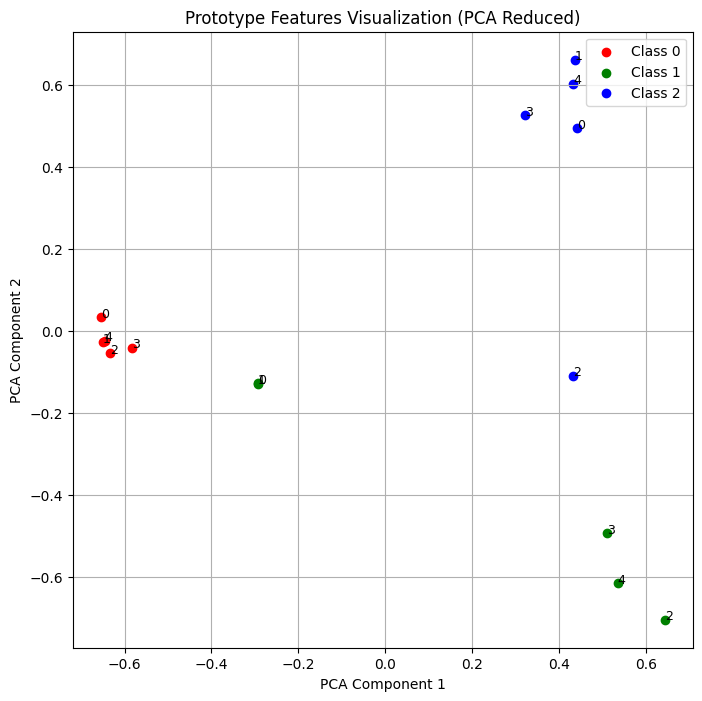

In [13]:
# 可视化原型特征
proto_features = proto_features.cpu().numpy()
num_class, num_prototype, feature_dim = proto_features.shape
# pca降维到2维
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
proto_features_2d = pca.fit_transform(proto_features.reshape(-1, feature_dim))
proto_features_2d = proto_features_2d.reshape(num_class, num_prototype, 2)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(8, 8))
for cls_idx in range(num_class):
    plt.scatter(proto_features_2d[cls_idx, :, 0], proto_features_2d[cls_idx, :, 1], 
                c=colors[cls_idx % len(colors)], label=f'Class {cls_idx}')
    for proto_idx in range(num_prototype):
        plt.text(proto_features_2d[cls_idx, proto_idx, 0], proto_features_2d[cls_idx, proto_idx, 1], 
                 str(proto_idx), fontsize=9)
plt.title('Prototype Features Visualization (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid()
plt.show()

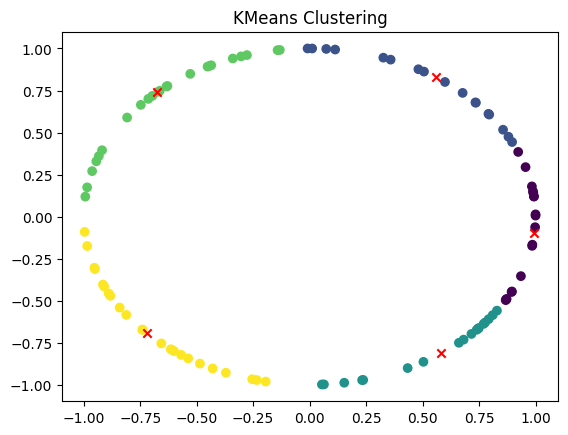

In [2]:
# Test KMeans clustering
x = torch.randn(100, 2)
x = x / x.norm(dim=-1, keepdim=True)  # Normalize to unit sphere
labels, centroids = kmeans(x, num_clusters=5, distance='cosine', norm=False)
labels2 = kmeans_predict(x, centroids)
plt.scatter(x[:, 0], x[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x')
plt.title('KMeans Clustering')
plt.show()

In [2]:
prototype_cfg = easydict.EasyDict({
    'PATH': 'test/prototype.pth',
    'NUM_CLASS': 3,
    'NUM_PROTO': 5,
    'BANK_SIZE': 20,
    'FEATURE_DIM': 2
})

In [3]:
proto_features, feature_bank, feature_count = load_prototype(prototype_cfg)

Prototype path test/prototype.pth does not exist!


In [4]:
save_prototype(proto_features, feature_bank, feature_count, prototype_cfg)

RuntimeError: Parent directory test does not exist.

In [42]:
new_features = [torch.randn(3, 2).cuda() for _ in range(prototype_cfg.NUM_CLASS)]
new_features = [new_features[i] / new_features[i].norm(dim=-1, keepdim=True) for i in range(len(new_features))]

In [43]:
proto_features, feature_bank, feature_count, feat2proto_count = \
        prototype_update(proto_features, feature_bank, feature_count, new_features, prototype_cfg.NUM_PROTO)

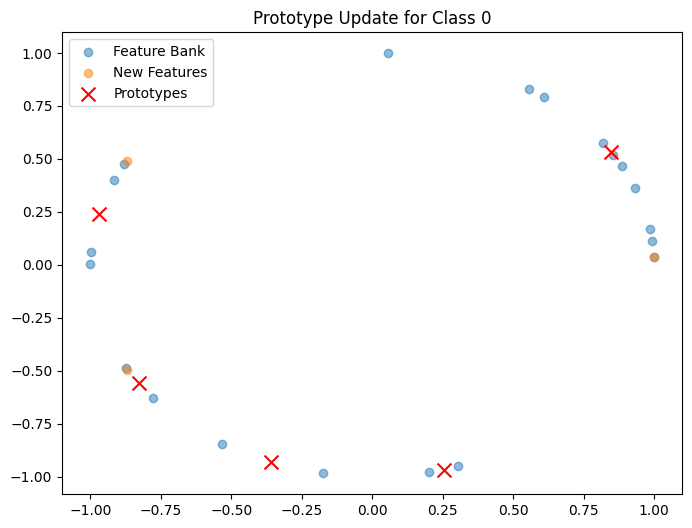

In [44]:
plt.figure(figsize=(8, 6))
class_id = 0
plt.scatter(feature_bank[class_id, :feature_count[class_id], 0].cpu(), 
            feature_bank[class_id, :feature_count[class_id], 1].cpu(), label='Feature Bank', alpha=0.5)
plt.scatter(new_features[class_id][:, 0].cpu(), new_features[class_id][:, 1].cpu(), label='New Features', alpha=0.5)
plt.scatter(proto_features[class_id].cpu()[:, 0], proto_features[class_id].cpu()[:, 1], label='Prototypes', color='red', marker='x', s=100)
plt.title(f'Prototype Update for Class {class_id}')
plt.legend()
plt.show()

In [2]:
def assign_target_of_single_head(num_classes, gt_boxes, feature_map_size, feature_map_stride, num_max_objs=500, gaussian_overlap=0.1, min_radius=2):
    """
    Args:
        gt_boxes: (N, 8)
        feature_map_size: (2), [x, y]

    Returns:

    """
    heatmap = gt_boxes.new_zeros(num_classes, feature_map_size[1], feature_map_size[0])
    ret_boxes = gt_boxes.new_zeros((num_max_objs, gt_boxes.shape[-1] - 1 + 1))
    inds = gt_boxes.new_zeros(num_max_objs).long()
    mask = gt_boxes.new_zeros(num_max_objs).long()
    ret_boxes_src = gt_boxes.new_zeros(num_max_objs, gt_boxes.shape[-1])
    ret_boxes_src[:gt_boxes.shape[0]] = gt_boxes

    x, y, z = gt_boxes[:, 0], gt_boxes[:, 1], gt_boxes[:, 2]
    coord_x = x / feature_map_stride
    coord_y = y / feature_map_stride
    coord_x = torch.clamp(coord_x, min=0, max=feature_map_size[0] - 0.5)  # bugfixed: 1e-6 does not work for center.int()
    coord_y = torch.clamp(coord_y, min=0, max=feature_map_size[1] - 0.5)  #
    center = torch.cat((coord_x[:, None], coord_y[:, None]), dim=-1)
    center_int = center.int()
    center_int_float = center_int.float()

    dx, dy, dz = gt_boxes[:, 3], gt_boxes[:, 4], gt_boxes[:, 5]
    dx = dx / feature_map_stride
    dy = dy / feature_map_stride

    radius = centernet_utils.gaussian_radius(dx, dy, min_overlap=gaussian_overlap)
    radius = torch.clamp_min(radius.int(), min=min_radius)

    for k in range(min(num_max_objs, gt_boxes.shape[0])):
        if dx[k] <= 0 or dy[k] <= 0:
            continue

        if not (0 <= center_int[k][0] <= feature_map_size[0] and 0 <= center_int[k][1] <= feature_map_size[1]):
            continue

        cur_class_id = (gt_boxes[k, -1] - 1).long()
        centernet_utils.draw_gaussian_to_heatmap(heatmap[cur_class_id], center[k], radius[k].item())

        inds[k] = center_int[k, 1] * feature_map_size[0] + center_int[k, 0]
        mask[k] = 1

        ret_boxes[k, 0:2] = center[k] - center_int_float[k].float()
        ret_boxes[k, 2] = z[k]
        ret_boxes[k, 3:6] = gt_boxes[k, 3:6].log()
        ret_boxes[k, 6] = torch.cos(gt_boxes[k, 6])
        ret_boxes[k, 7] = torch.sin(gt_boxes[k, 6])
        if gt_boxes.shape[1] > 8:
            ret_boxes[k, 8:] = gt_boxes[k, 7:-1]

    return heatmap, ret_boxes, inds, mask, ret_boxes_src

In [3]:
def prototype_learning(x, target_dict, proto_features, feat2proto_count, new_features, new_features_labels):
    """
    Args:
        x: (B, C, H, W)
        target_dict:
            'heatmaps': list of (B, num_classes, H, W)
            'target_boxes': list of (B, M, 8)
            'inds': list of (B, M)
            'masks': list of (B, M)
            'target_boxes_src': list of (B, M, 9)

    Returns:

    """
    # feature extraction
    feats = F.normalize(x, p=2, dim=-1)

    # compute cosine similarity and assign prototypes
    cos_sim = (feats[:, :, :, None, None, None, :] @ proto_features[None, None, None, :, :, :, None]).squeeze(-1, -2)  # (B, H, W, NUM_CLASS, NUM_PROTO)
    max_sim, max_proto_ids = cos_sim.max(dim=-1)  # (B, H, W, NUM_CLASS)
    cos_sim_rect = cos_sim / (feat2proto_count + 1).log().clamp(min=1.0)[None, None, None, :, :]
    max_sim_rect, max_proto_ids_rect = cos_sim_rect.max(dim=-1)  # (B, H, W, NUM_CLASS)
    
    for idx, cur_class_ids in enumerate([torch.tensor([0, 1, 2]).cuda()]):
        heatmaps = target_dict['heatmaps'][idx]  # (B, num_classes, H, W)

        # collect gt features for prototype updating
        gt_inds = torch.where(heatmaps == 1)  # (4, M) (B, class_id, y, x)
        gt_feats = feats[gt_inds[0], gt_inds[2], gt_inds[3], :]  # (M, D)
        gt_class_ids = cur_class_ids[gt_inds[1]]  # (M,)
        gt_proto_ids = max_proto_ids_rect[gt_inds[0], gt_inds[2], gt_inds[3], gt_class_ids]  # (M,)
        for class_id in cur_class_ids:
            class_mask = (gt_class_ids == class_id)
            if class_mask.sum() == 0:
                continue
            class_feats = gt_feats[class_mask]  # (N_c, D)
            new_features[class_id] = torch.cat([new_features[class_id], class_feats], dim=0)
            new_features_labels[class_id] = torch.cat([new_features_labels[class_id], gt_proto_ids[class_mask]], dim=0)

        # remove gt positions from max_sim to avoid duplicate counting
        heatmap_inds = torch.where(heatmaps > 0)  # (4, N) (B, class_id, y, x)
        max_sim[heatmap_inds[0], heatmap_inds[2], heatmap_inds[3], cur_class_ids[heatmap_inds[1]]] = 0

    max_sim, max_class_ids = max_sim.max(dim=-1)  # (B, H, W)

    # collect similar features for prototype updating
    sim_mask = (max_sim > 0.3)
    for class_id in range(3):
        class_mask = (max_class_ids == class_id) & sim_mask  # (B, H, W)
        if class_mask.sum() == 0:
            continue
        class_feats = feats[class_mask]  # (N_c, D)
        new_features[class_id] = torch.cat([new_features[class_id], class_feats], dim=0)
        new_features_labels[class_id] = torch.cat([new_features_labels[class_id], max_proto_ids_rect[class_mask][:, class_id]], dim=0)

    # collect pseudo-labeled features and refine heatmaps
    pseudo_mask = (max_sim > 0.3)
    for idx, cur_class_ids in enumerate([torch.tensor([0, 1, 2]).cuda()]):
        pseudo_heatmap = torch.zeros_like(target_dict['heatmaps'][idx])  # (B, num_classes, H, W)
        for i, class_id in enumerate(cur_class_ids):
            class_mask = (max_class_ids == class_id) & pseudo_mask  # (B, H, W)
            pseudo_heatmap[:, i, :, :][class_mask] = max_sim[:, :, :][class_mask]
        target_dict['heatmaps'][idx] = torch.clamp_max(target_dict['heatmaps'][idx] + pseudo_heatmap, max=1.0)

    return target_dict, new_features, new_features_labels

In [4]:
prototype_cfg = easydict.EasyDict({
    'PATH': 'prototype.pth',
    'NUM_CLASS': 3,
    'NUM_PROTO': 10,
    'BANK_SIZE': 100,
    'FEATURE_DIM': 128
})
proto_features, feature_bank, feature_count = load_prototype(prototype_cfg)
feature_map_size = (30, 30)
feature_map_stride = 1

gt_boxes = torch.tensor([
    [10.0, 15.0, 0.0, 4.0, 2.0, 1.5, 0.0, 1],
    [5.0, 5.0, 0.0, 3.0, 3.0, 1.5, 1.57, 2],
    [25.0, 20.0, 0.0, 5.0, 2.5, 1.5, -1.57, 3]
]).cuda()

heatmap, ret_boxes, inds, mask, ret_boxes_src = assign_target_of_single_head(
    num_classes=3,
    gt_boxes=gt_boxes,
    feature_map_size=feature_map_size,
    feature_map_stride=feature_map_stride
)

target_dict = {
    'heatmaps': [heatmap.unsqueeze(0)],
    'target_boxes': [ret_boxes.unsqueeze(0)],
    'inds': [inds.unsqueeze(0)],
    'masks': [mask.unsqueeze(0)],
    'target_boxes_src': [ret_boxes_src.unsqueeze(0)]
}

Prototype path prototype.pth does not exist!


In [40]:
x = torch.randn(1, feature_map_size[1], feature_map_size[0], prototype_cfg.FEATURE_DIM).cuda()
new_features = [torch.zeros((0, prototype_cfg.FEATURE_DIM)).float().cuda() for _ in range(prototype_cfg.NUM_CLASS)]
new_features_labels = [torch.zeros((0,), dtype=torch.long).cuda() for _ in range(prototype_cfg.NUM_CLASS)]
target_dict, new_features, new_features_labels = prototype_learning(
    x,
    target_dict,
    proto_features,
    feat2proto_count,
    new_features,
    new_features_labels
)

In [36]:
print([feat.shape for feat in new_features])

[torch.Size([6, 128]), torch.Size([3, 128]), torch.Size([4, 128])]


In [9]:
new_features = [torch.randn(40, 128).cuda() for _ in range(prototype_cfg.NUM_CLASS)]
new_features = [new_features[i] / new_features[i].norm(dim=-1, keepdim=True) for i in range(len(new_features))]

In [10]:
proto_features, feature_bank, feature_count, feat2proto_count = \
        prototype_update(proto_features, feature_bank, feature_count, new_features, prototype_cfg.NUM_PROTO)

In [16]:
feat2proto_count

tensor([[2, 1, 3, 2, 2, 2, 1, 3, 2, 2],
        [1, 4, 1, 1, 3, 1, 2, 4, 1, 2],
        [2, 3, 1, 4, 1, 2, 1, 2, 2, 2]], device='cuda:0')

In [42]:
# display heatmaps using cv2
heatmap = target_dict['heatmaps'][0][0]  # (num_classes, H, W)
heatmap_np = heatmap.cpu().numpy().transpose(1, 2, 0)
heatmap_vis = (heatmap_np * 255).astype(np.uint8)
cv2.imshow('Heatmap', heatmap_vis)
cv2.waitKey(0)
# cv2.destroyAllWindows()

225

In [43]:
cv2.destroyAllWindows()